In [ ]:
"""You are working on a global research project for SDG 13: Climate Action. Your team is analyzing relationships between key climate indicators across five countries:

    CO₂ emissions per capita
    Mean annual temperature anomaly
    Deforestation rate

Your goal is to compute and interpret a correlation matrix to understand how these variables move together."""

In [2]:
climate <- matrix(c(
  9.2, 1.1, 0.8,
  6.5, 0.9, 1.2,
  2.3, 0.7, 2.5,
  3.8, 1.0, 1.5,
  7.1, 1.2, 0.9
), nrow=5, byrow=TRUE)

colnames(climate) <- c("CO2", "Temp", "Deforestation")
rownames(climate) <- c("A", "B", "C", "D", "E")

print(climate) # matrix represents data from five countries. Each column is a variable.

  CO2 Temp Deforestation
A 9.2  1.1           0.8
B 6.5  0.9           1.2
C 2.3  0.7           2.5
D 3.8  1.0           1.5
E 7.1  1.2           0.9


In [3]:
scaled_climate <- scale(climate)
print(scaled_climate)

#Why is it important to scale your data before computing correlation?
#Scaling is about units, scale and magnitude. It converts everything to the same unit. 
# so no variable dominates purely because of its unit of measurement, not because it's actually more influential in the real world

         CO2       Temp Deforestation
A  1.2490573  0.6238503    -0.8487300
B  0.2629594 -0.4159002    -0.2633990
C -1.2709706 -1.4556507     1.6389269
D -0.7231384  0.1039750     0.1755993
E  0.4820923  1.1437255    -0.7023972
attr(,"scaled:center")
          CO2          Temp Deforestation 
         5.78          0.98          1.38 
attr(,"scaled:scale")
          CO2          Temp Deforestation 
    2.7380650     0.1923538     0.6833740 


In [4]:
cor_matrix <- cor(scaled_climate)
print(cor_matrix)

#This gives a square, symmetric matrix that shows how variables relate to one another.

                     CO2       Temp Deforestation
CO2            1.0000000  0.7490355    -0.9195016
Temp           0.7490355  1.0000000    -0.8976824
Deforestation -0.9195016 -0.8976824     1.0000000


In [ ]:
#Which two variables are most strongly positively correlated?
    #There is only ONE most strongly positively correlation which is CO2 <-> Temp: 0.749
#Is any variable negatively correlated with another?
    #There are two, CO2 <-> Deforestation: 0.921 and Temp <-> Deforestation: -0.898
#Which variables show weak or no correlation?
    #N/A

In [5]:
climate <- rbind(climate, c(10.0, 1.5, 0.4)) #Adding new country
rownames(climate)[6] <- "F"

scaled_climate <- scale(climate)
cor_matrix <- cor(scaled_climate)
print(cor_matrix)

                     CO2       Temp Deforestation
CO2            1.0000000  0.8327314    -0.9443520
Temp           0.8327314  1.0000000    -0.8983852
Deforestation -0.9443520 -0.8983852     1.0000000


In [ ]:
#What changed? Did the correlations get stronger, weaker, or flip direction? Why?
    #CO2 <-> Temp value got stronger: 0.749 -> 00.833
    #Temp <-> Deforestation remained the same, while CO2 <-> Deforestation became weaker than greatly negative: -0.898 -> 0.944

Warning message:
"package 'ggplot2' is in use and will not be installed"


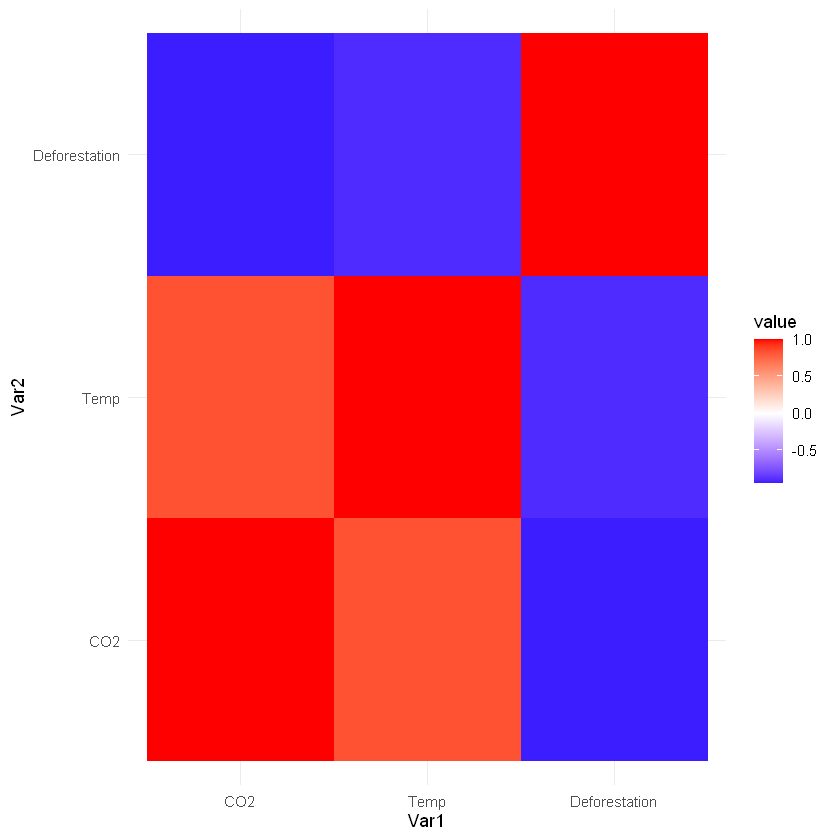

In [11]:
install.packages("ggplot2")
library(reshape2)
library(ggplot2)

melted <- melt(cor_matrix)

ggplot(melted, aes(Var1, Var2, fill = value)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0) +
  theme_minimal()